In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

#from simpledbf import Dbf5
#import openpyxl
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.cluster import KMeans

In [14]:
agebs_gdf = gpd.read_file("26/ageb_urb.shp").to_crs("4326").cx[-111.25:-110.75, 28.9:29.3].reset_index()
agebs_gdf.head()

,index,CVEGEO,POB1,POB2,POB2_R,POB3,POB3_R,POB4,POB4_R,POB5,...,POB78,POB78_R,POB79,POB79_R,POB80,POB80_R,POB81,POB81_R,OID,geometry
0,1016,2603000010023,0,-6,-6.0,-6,-6.0,-6,-6.0,-6,...,-6,-6.0,-6,-6.0,-6,-6.0,-6,-6.0,1017,"POLYGON ((-110.99153 29.06045, -110.99091 29.0..."
1,1017,2603000010076,6,-6,-6.0,-6,-6.0,-6,-6.0,-6,...,-6,-6.0,-6,-6.0,-6,-6.0,-6,-6.0,1018,"POLYGON ((-111.03254 29.1459, -111.03275 29.14..."
2,1018,2603000010080,0,0,-8.0,0,-8.0,0,-8.0,0,...,0,-8.0,0,-8.0,0,-8.0,0,-8.0,1019,"POLYGON ((-111.02556 29.16581, -111.02558 29.1..."
3,1019,2603000010095,218,22,10.1,32,14.7,13,6.0,19,...,53,49.1,0,0.0,0,0.0,0,0.0,1020,"POLYGON ((-111.00192 29.16435, -111.00197 29.1..."
4,1020,2603000010108,0,0,-8.0,0,-8.0,0,-8.0,0,...,0,-8.0,0,-8.0,0,-8.0,0,-8.0,1021,"POLYGON ((-110.98598 29.16559, -110.9871 29.16..."


In [18]:
data = pd.read_csv("nominal_data_dengue_2010.csv")
data_by_date = pd.read_csv("gdf_clustered.csv")
gdf = gpd.GeoDataFrame(
    data_by_date, geometry=gpd.points_from_xy(data_by_date["x"], data_by_date["y"]), crs="EPSG:4326"
)
gdf["x"] = data_by_date["x"]
gdf["y"] = data_by_date["y"]
gdf.head()

,Unnamed: 0,I_CUADRO,OBJECTID,Join_Count,TARGET_FID,ID_HILLO,ID_SON,ANYO,FOLIO,SEXO,...,Unnamed: 69,day,week,month,year,dayofyear,FD,FHD,geometry,cluster_kmeans
0,22,2010-08-30,20,1,236,250,6904,0,929,mujer,...,NaN,30,35,8,2010,242,0,1,POINT (-111.0155 29.13418),0
1,23,2010-09-01,25,1,241,255,6927,0,976,hombre,...,NaN,1,35,9,2010,244,0,1,POINT (-110.96435 29.13623),0
2,24,2010-09-02,26,1,242,256,6928,0,977,mujer,...,NaN,2,35,9,2010,245,1,0,POINT (-110.96647 29.1374),0
3,25,2010-09-02,27,1,243,257,6929,0,978,hombre,...,NaN,2,35,9,2010,245,1,0,POINT (-110.96414 29.13722),0
4,26,2010-09-02,33,1,249,262,6944,0,997,hombre,...,NaN,2,35,9,2010,245,1,0,POINT (-110.9677 29.12675),0


<Axes: >

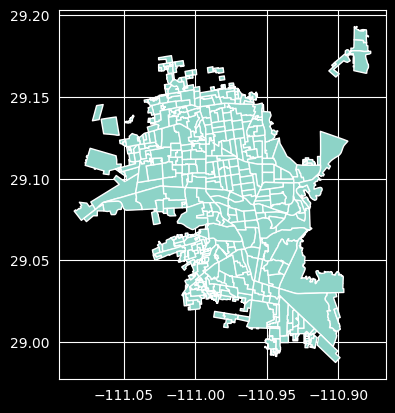

In [19]:
agebs_gdf.plot()

In [23]:
kmeans_df = gdf[["x", "y", "SEXO", "EDAD", "GRADO_MA_1", "DENSI_POB", "week", "FD_FHD"]]
kmeans_df.set_index(np.arange(len(kmeans_df)), inplace=True)

sexo_df = pd.get_dummies(kmeans_df["SEXO"], dtype="int", drop_first=True)
kmeans_df = pd.concat([kmeans_df, sexo_df], axis=1)
kmeans_df.drop("SEXO", axis=1, inplace=True)

fd_fhd_df = pd.get_dummies(kmeans_df["FD_FHD"], dtype="int", drop_first=True)
kmeans_df = pd.concat([kmeans_df, fd_fhd_df], axis=1)
kmeans_df.drop("FD_FHD", axis=1, inplace=True)

kmeans_df.columns = ["x", "y", "edad", "grad_marg", "densi_pob", "semana", "sexo", "FHD"]

kmeans_df.head()

,x,y,edad,grad_marg,densi_pob,semana,sexo,FHD
0,-111.015505,29.134184,0,3,77.445107,35,1,1
1,-110.964347,29.136228,41,3,122.000382,35,0,1
2,-110.966473,29.137403,47,3,122.000382,35,1,0
3,-110.964142,29.137217,8,3,122.000382,35,0,0
4,-110.967696,29.126753,30,2,83.995697,35,0,0


<Axes: >

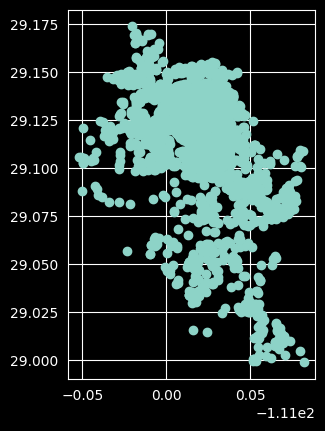

In [24]:
gdf.plot()

In [25]:
standard_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()
standard_scaled_df = pd.DataFrame(standard_scaler.fit_transform(kmeans_df.drop(["sexo", "grad_marg", "semana", "FHD"], axis=1)))
min_max_scaled_df = pd.DataFrame(min_max_scaler.fit_transform(kmeans_df[["grad_marg", "semana"]]))
standard_scaled_df.columns = ["x", "y", "edad", "densi_pob"]
min_max_scaled_df.columns = ["grad_marg", "semana"]

In [26]:
kmeans_df = pd.concat([standard_scaled_df, min_max_scaled_df, kmeans_df["sexo"]], axis=1)
kmeans_df.head()

,x,y,edad,densi_pob,grad_marg,semana,sexo
0,-1.700815,0.707979,-1.704933,-0.014793,0.50,0.0,1
1,0.620166,0.777090,0.462566,1.490939,0.50,0.0,0
2,0.523707,0.816815,0.779761,1.490939,0.50,0.0,1
3,0.629439,0.810517,-1.282006,1.490939,0.50,0.0,0
4,0.468217,0.456710,-0.118958,0.206582,0.25,0.0,0


In [27]:
kmeans_df.isna().sum()

x            0
y            0
edad         0
densi_pob    0
grad_marg    0
semana       0
sexo         0
dtype: int64

In [16]:
kmeans = KMeans(n_clusters=4).fit(kmeans_df)
kmeans.labels_

array([3, 3, 3, ..., 3, 0, 3], shape=(2728,), dtype=int32)

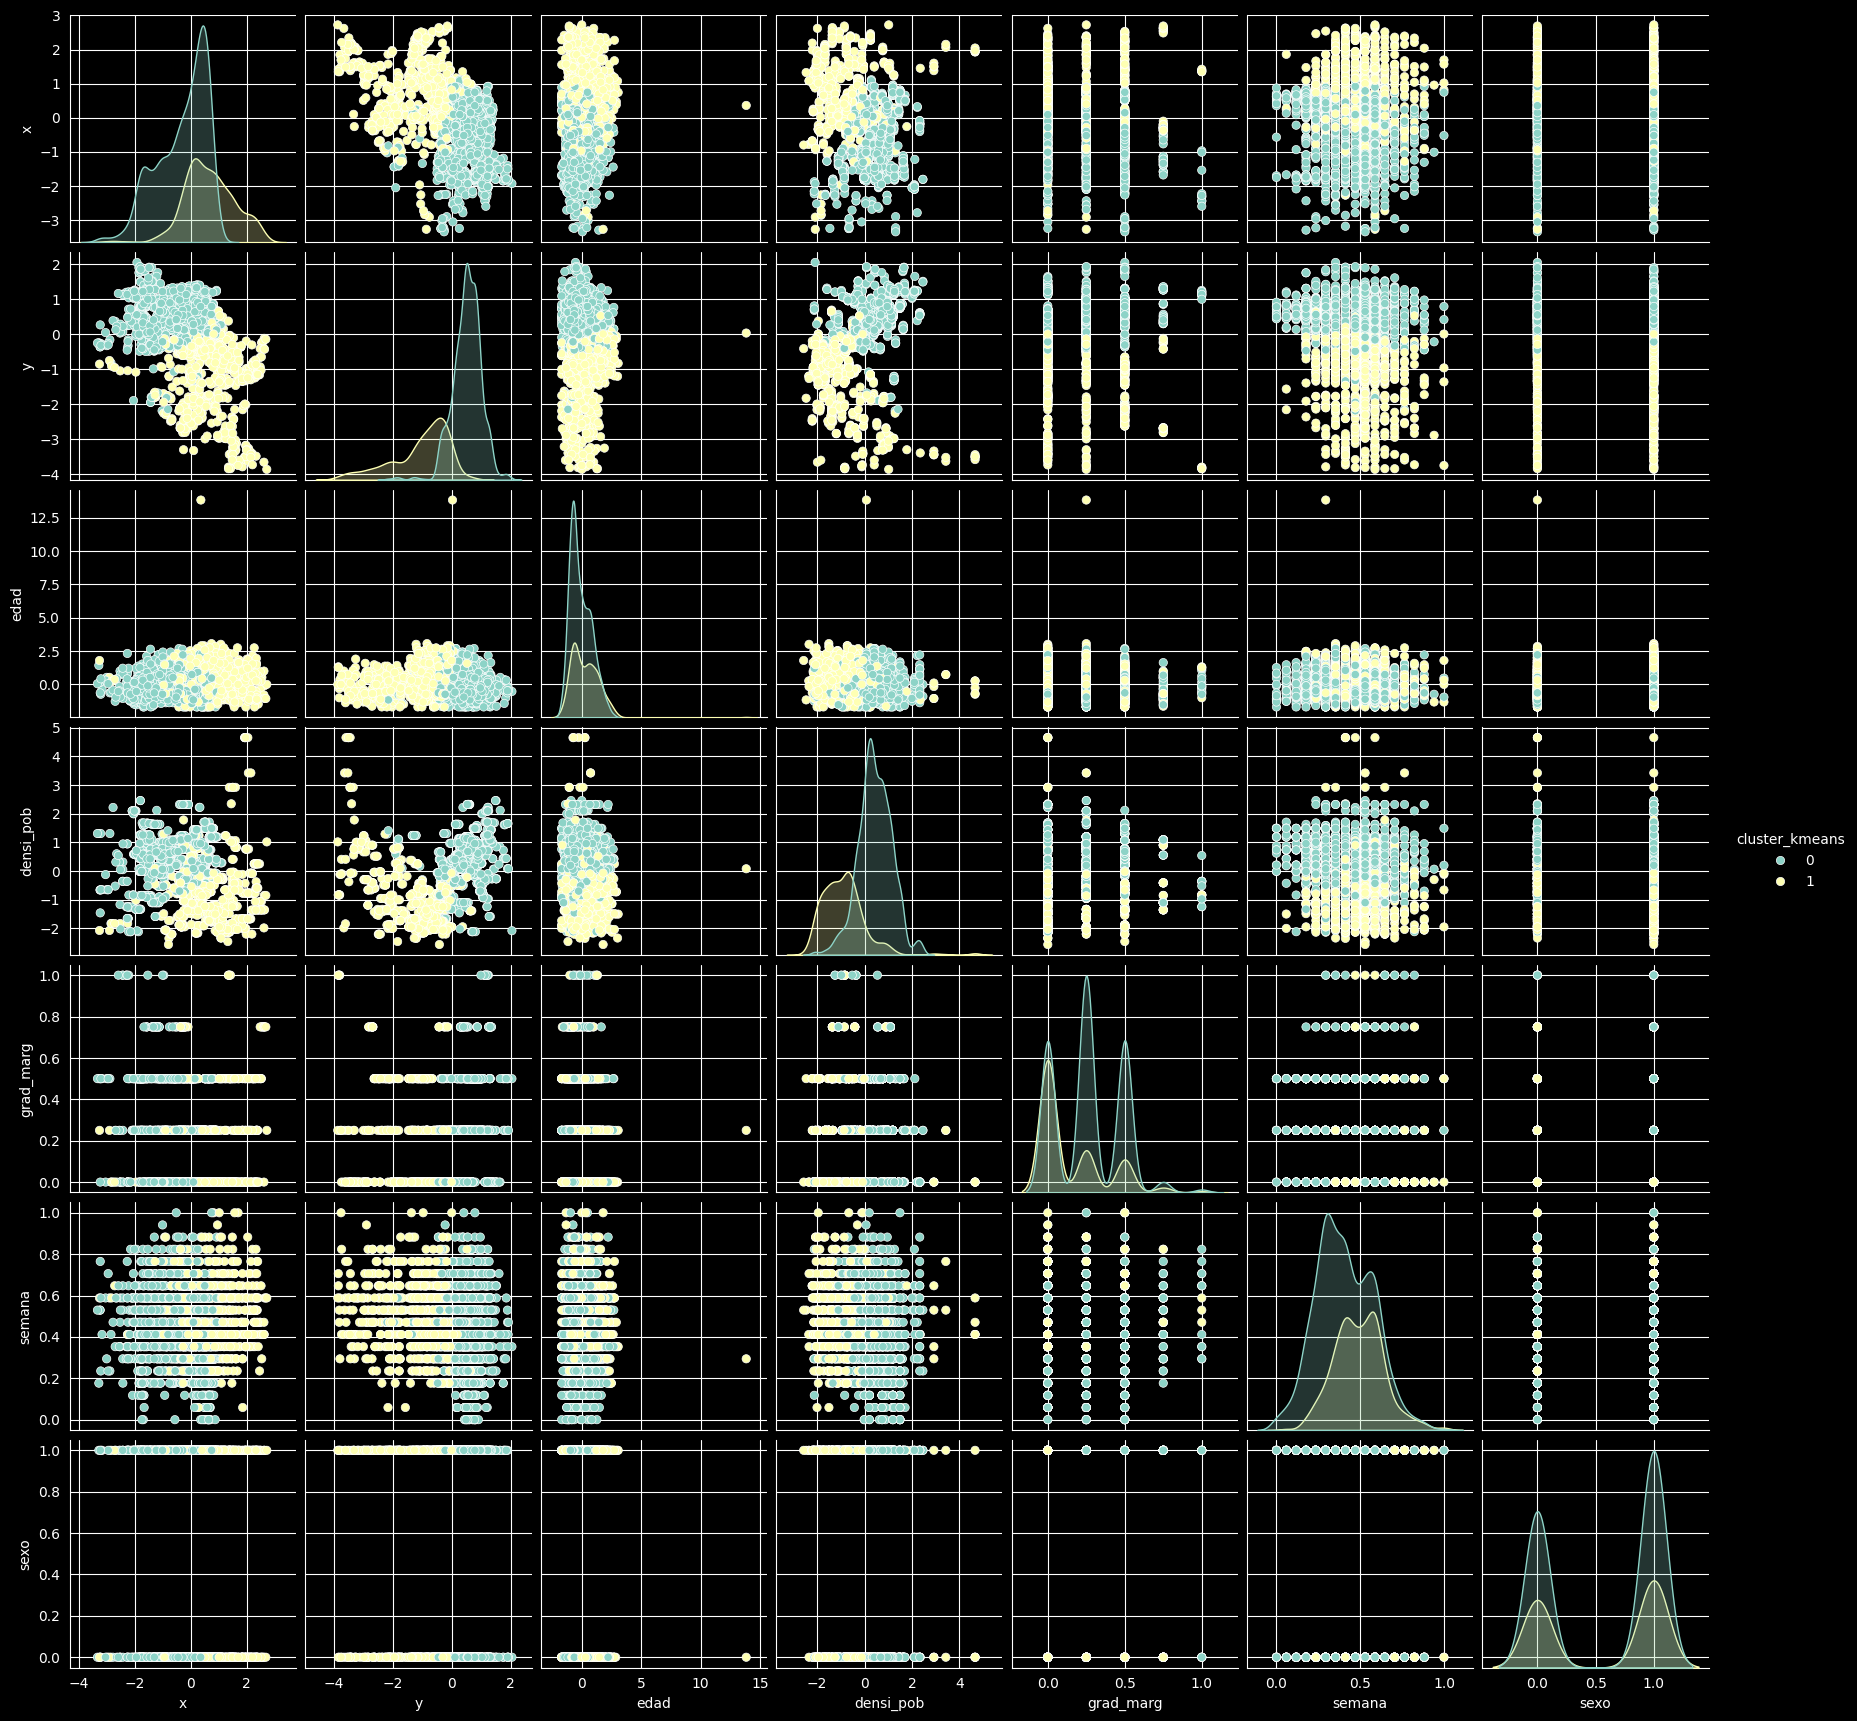

In [30]:
kmeans_df["cluster_kmeans"] = gdf["cluster_kmeans"]
pairplot_kmeans = sns.pairplot(kmeans_df, hue="cluster_kmeans")

# Obteniendo Población por AGEBs de cada Cluster

In [31]:
gdf

,Unnamed: 0,I_CUADRO,OBJECTID,Join_Count,TARGET_FID,ID_HILLO,ID_SON,ANYO,FOLIO,SEXO,...,Unnamed: 69,day,week,month,year,dayofyear,FD,FHD,geometry,cluster_kmeans
0,22,2010-08-30,20,1,236,250,6904,0,929,mujer,...,NaN,30,35,8,2010,242,0,1,POINT (-111.0155 29.13418),0
1,23,2010-09-01,25,1,241,255,6927,0,976,hombre,...,NaN,1,35,9,2010,244,0,1,POINT (-110.96435 29.13623),0
2,24,2010-09-02,26,1,242,256,6928,0,977,mujer,...,NaN,2,35,9,2010,245,1,0,POINT (-110.96647 29.1374),0
3,25,2010-09-02,27,1,243,257,6929,0,978,hombre,...,NaN,2,35,9,2010,245,1,0,POINT (-110.96414 29.13722),0
4,26,2010-09-02,33,1,249,262,6944,0,997,hombre,...,NaN,2,35,9,2010,245,1,0,POINT (-110.9677 29.12675),0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2701,2723,2010-12-28,2345,2,2562,2688,11089,0,5648,mujer,...,NaN,28,52,12,2010,362,1,0,POINT (-110.95999 29.11326),1
2702,2724,2010-12-28,2348,1,2565,2691,11093,0,5652,mujer,...,NaN,28,52,12,2010,362,0,1,POINT (-110.94337 29.08464),1
2703,2725,2010-12-31,2352,1,2569,2695,11113,0,5676,mujer,...,NaN,31,52,12,2010,365,1,0,POINT (-110.96156 29.13656),0
2704,2726,2010-12-31,2353,1,2570,2696,11114,0,5677,hombre,...,NaN,31,52,12,2010,365,1,0,POINT (-110.95555 29.07282),1


In [33]:
gdf_cluster_0 = gdf[gdf["cluster_kmeans"] == 0]
gdf_cluster_1 = gdf[gdf["cluster_kmeans"] == 1]

<Axes: >

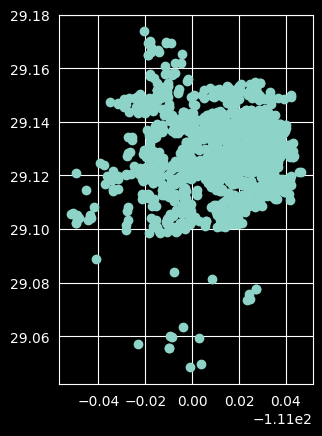

In [34]:
gdf_cluster_0.plot()

In [35]:
joined_cluster_0 = gpd.sjoin(agebs_gdf, gdf_cluster_0, how='inner', predicate='contains')
joined_cluster_1 = gpd.sjoin(agebs_gdf, gdf_cluster_1, how='inner', predicate='contains')

# Get the unique polygon indices that contain at least one point
agebs_with_points_0 = joined_cluster_0.index.unique()
agebs_with_points_1 = joined_cluster_1.index.unique()

# Filter the original polygon dataframe
agebs_cluster_0 = agebs_gdf.loc[agebs_with_points_0]
agebs_cluster_1 = agebs_gdf.loc[agebs_with_points_1]


Text(0.5, 1.0, 'Cluster 1')

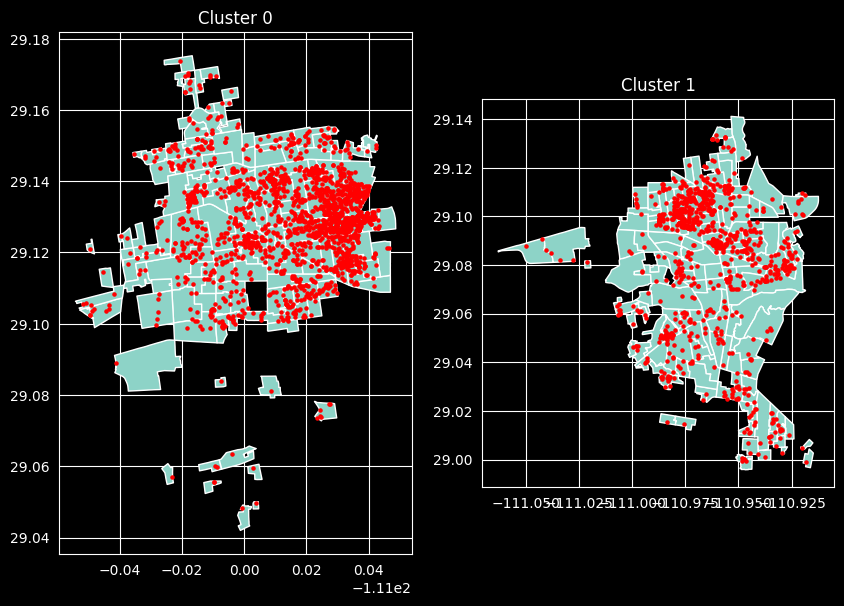

In [40]:
fig, axes = plt.subplots(1,2,figsize=(10,10))
agebs_cluster_0.plot(ax=axes[0])
gdf_cluster_0.plot(ax=axes[0], color="red", markersize=5)
axes[0].set_title("Cluster 0")

agebs_cluster_1.plot(ax=axes[1])
gdf_cluster_1.plot(ax=axes[1], color="red", markersize=5)
axes[1].set_title("Cluster 1")




In [39]:
pob_total_cluster_0 = agebs_cluster_0["POB1"].sum()
pob_total_cluster_1 = agebs_cluster_1["POB1"].sum()
pob_total = pob_total_cluster_0 + pob_total_cluster_1

print(f"Población total de Cluster 0:\t{pob_total_cluster_0}")
print(f"Población total de Cluster 1:\t{pob_total_cluster_1}")
print(f"Población total:\t\t\t\t{pob_total}")

Población total de Cluster 0:	369930
Población total de Cluster 1:	341387
Población total:				711317
